In [9]:
!unzip "/content/archive (1).zip" -d "/content/unzipped_files"

Archive:  /content/archive (1).zip
  inflating: /content/unzipped_files/BankChurners.csv  


#  Bank Customer Churn Prediction: Classification Project

## Introduction and Setup

Customer churn is a critical problem for banks. Predicting which customers are likely to leave allows the bank to intervene proactively. This notebook performs an Exploratory Data Analysis (EDA) on the BankChurners dataset and develops several machine learning models to classify customers as "Existing Customer" or "Attrited Customer."

We will focus on maximizing the F1-Score for the minority class ("Attrited Customer") to ensure we correctly identify potential leavers (high recall) without an excessive number of false positives (good precision).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import  classification_report,make_scorer,f1_score


import warnings
warnings.filterwarnings('ignore')

In [19]:
df = pd.read_csv("/content/unzipped_files/BankChurners.csv")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [9]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [10]:
df = df.drop([
    'CLIENTNUM',
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"
], axis=1)

# EDA

Customer Age vs. Attrition

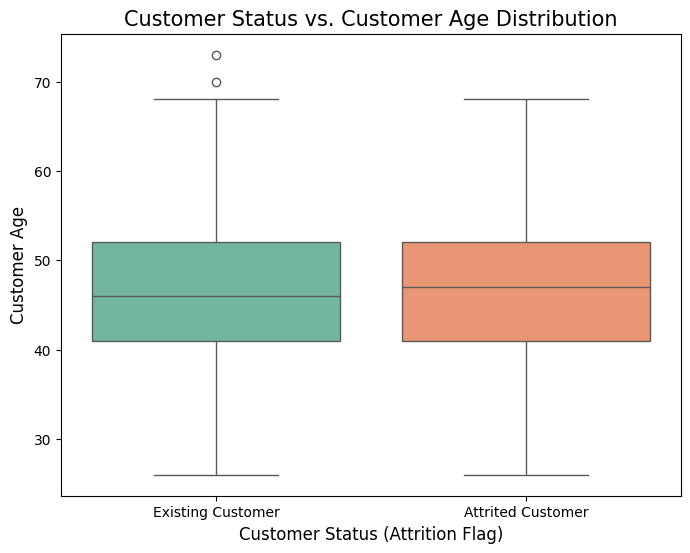

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Attrition_Flag", y="Customer_Age", palette="Set2")
plt.title("Customer Status vs. Customer Age Distribution", fontsize=15)
plt.xlabel("Customer Status (Attrition Flag)", fontsize=12)
plt.ylabel("Customer Age", fontsize=12)
plt.show()

Revolving Balance vs. Attrition

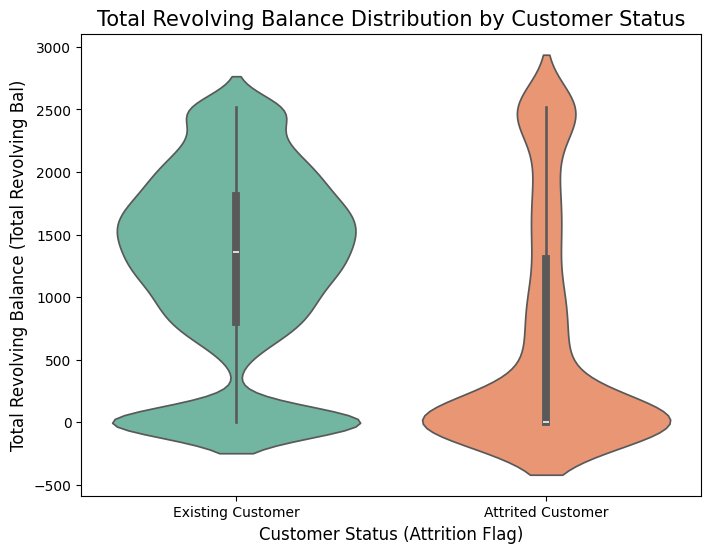

> Insight: Attrited Customers tend to have a lower revolving balance, showing two distinct peaks at the lower end.


In [12]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Attrition_Flag', y='Total_Revolving_Bal', data=df, palette='Set2')
plt.title('Total Revolving Balance Distribution by Customer Status', fontsize=15)
plt.xlabel('Customer Status (Attrition Flag)', fontsize=12)
plt.ylabel('Total Revolving Balance (Total Revolving Bal)', fontsize=12)
plt.show()

print("> Insight: Attrited Customers tend to have a lower revolving balance, showing two distinct peaks at the lower end.")

**Transaction Change vs. Contacts Count (Key Insight)**

The scatter plot and correlation were critical in identifying a relationship between contact frequency and transaction habits, which appears to be a strong indicator of churn.

The scatter plot showed:

Attrited Customers (Red) are predominantly concentrated in the lower-left quadrant (low change in transaction count and amount).

Existing Customers (Blue) are generally scattered across higher change values.



Correlation between Total_Ct_Chng_Q4_Q1 and Contacts_Count_12_mon: -0.095


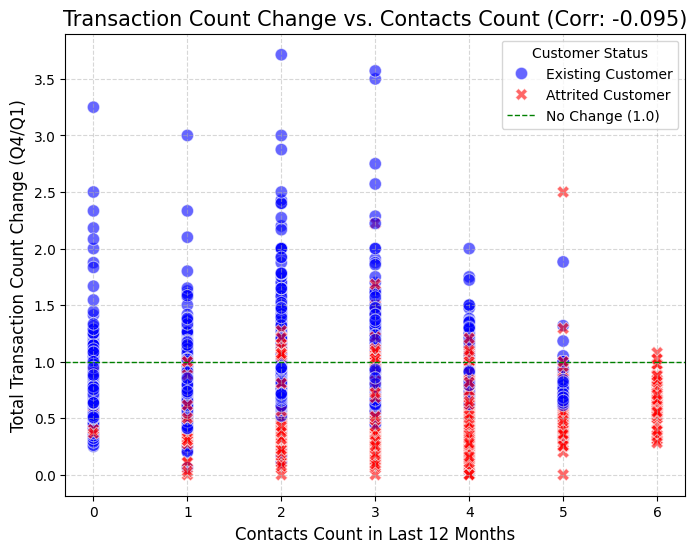

In [13]:
corr = df['Total_Ct_Chng_Q4_Q1'].corr(df['Contacts_Count_12_mon'])
print(f"Correlation between Total_Ct_Chng_Q4_Q1 and Contacts_Count_12_mon: {corr:.3f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='Contacts_Count_12_mon',
    y='Total_Ct_Chng_Q4_Q1',
    hue='Attrition_Flag',
    style='Attrition_Flag',
    palette={'Existing Customer': 'blue', 'Attrited Customer': 'red'},
    alpha=0.6,
    s=80
)
plt.axhline(y=1.0, color='green', linestyle='--', linewidth=1, label='No Change (1.0)')
plt.title(f'Transaction Count Change vs. Contacts Count (Corr: {corr:.3f})', fontsize=15)
plt.xlabel('Contacts Count in Last 12 Months', fontsize=12)
plt.ylabel('Total Transaction Count Change (Q4/Q1)', fontsize=12)
plt.legend(title='Customer Status')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


The correlation was calculated as -0.095. While numerically small, the EDA suggests a pattern where an increase in Contacts_Count_12_mon (i.e., customer service calls) is associated with a decrease in transaction activity (Total_Ct_Chng_Q4_Q1): More service calls + fewer transactions = Higher likelihood of churn.

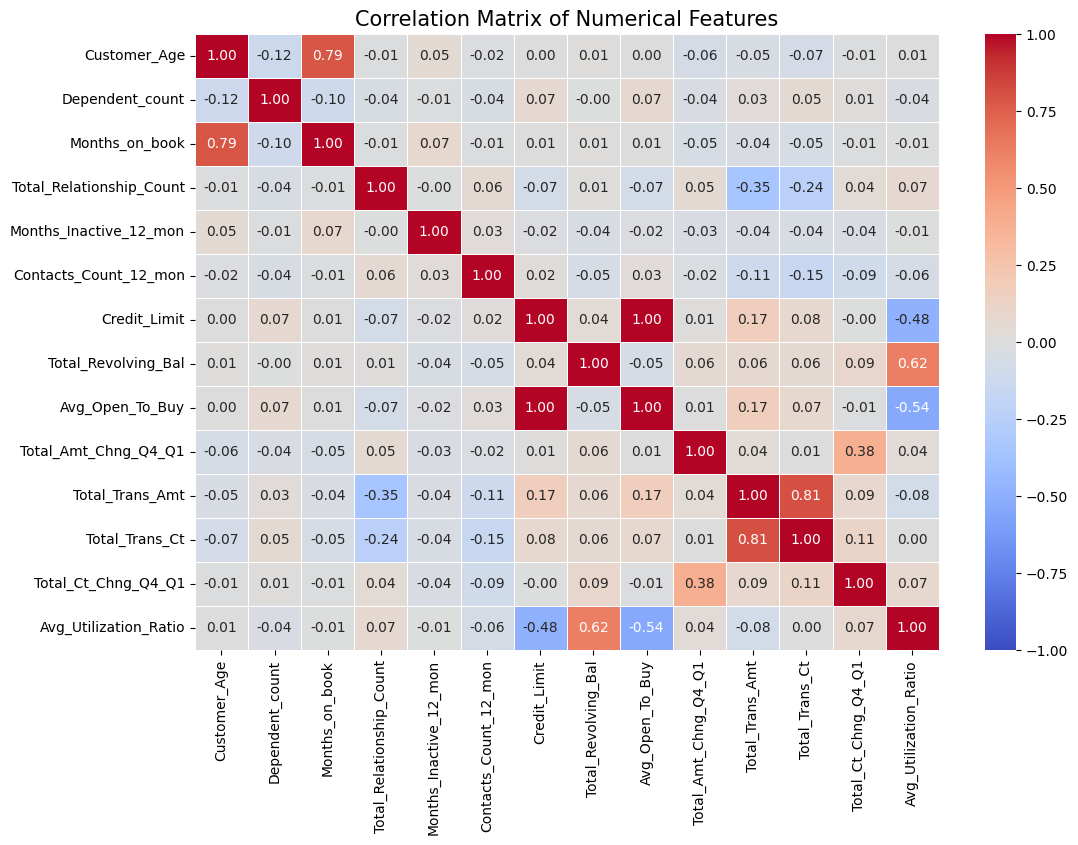

In [14]:
numerical_cols_updated = df.select_dtypes(include=['number']).columns.tolist()
analysis_df = df[numerical_cols_updated]
corr_matrix = analysis_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('Correlation Matrix of Numerical Features', fontsize=15)
plt.show()

df = df.drop(["Avg_Open_To_Buy"], axis=1)

**Feature Correlation**

The original notebook checked correlations among numerical features. The insight here is that Avg_Open_To_Buy and Credit_Limit are highly correlated (0.99), suggesting one can be removed to reduce multicollinearity.

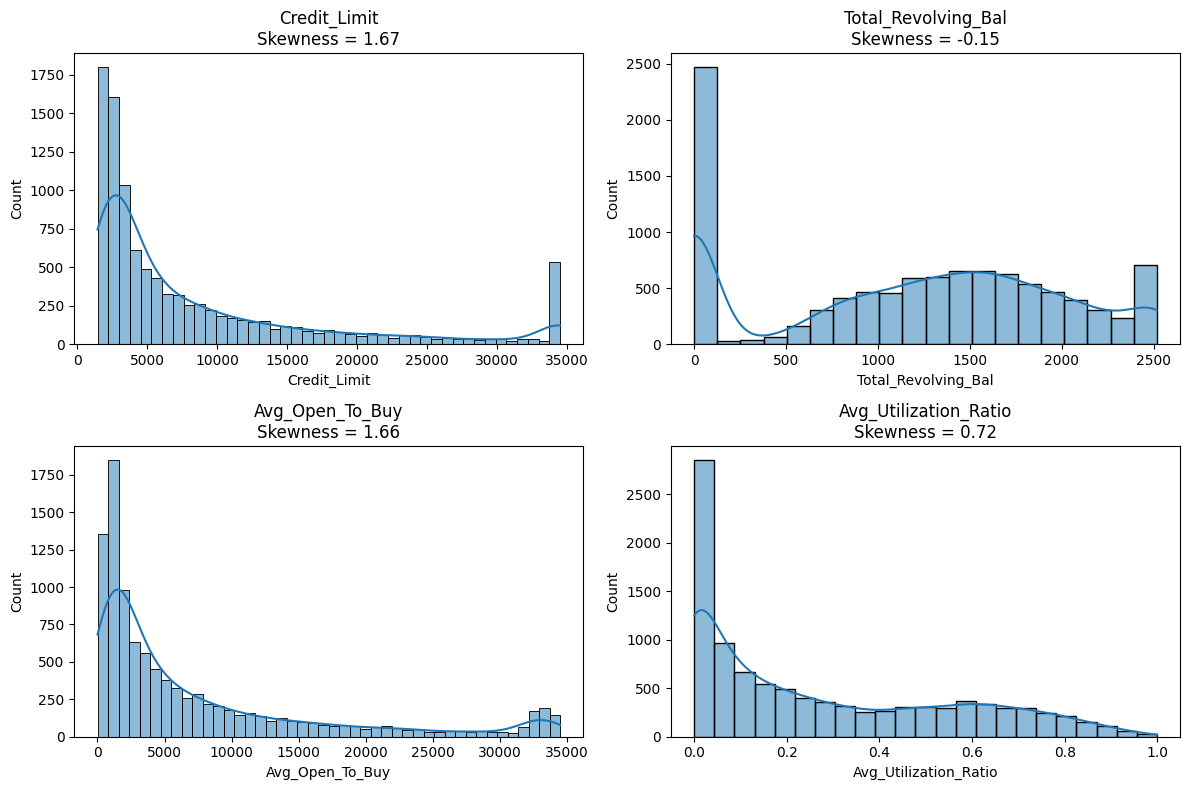

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    "Credit_Limit",
    "Total_Revolving_Bal",
    "Avg_Open_To_Buy",
    "Avg_Utilization_Ratio"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), features):
    sns.histplot(
        df[feature],
        kde=True,
        ax=ax
    )

    skewness = df[feature].skew()

    ax.set_title(
        f"{feature}\nSkewness = {skewness:.2f}"
    )

plt.tight_layout()
plt.show()

# Data Preprocessing and Splitting

In [24]:
df = pd.read_csv("/content/unzipped_files/BankChurners.csv")

In [25]:
df = df.drop([
    'CLIENTNUM',
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"
], axis=1)

In [26]:

categorical_cols = ["Gender", "Education_Level", "Marital_Status", "Income_Category", "Card_Category"]
df = pd.get_dummies(df, columns=categorical_cols, dtype=int)


df_target = df["Attrition_Flag"]
df_features = df.drop("Attrition_Flag", axis=1)

X = df_features
y = df_target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# Classification Modeling and Evaluation

We use three different classifiers and tune their hyperparameters using GridSearchCV. We focus on the F1-Score as the primary metric for optimization, as it balances Precision and Recall for the minority (churn) class. We also use class_weight='balanced' to address the class imbalance.

**The target classes are:**

Attrited Customer (Minority Class, where Recall is critical)

Existing Customer (Majority Class)

In [18]:
f1_scorer_churn = make_scorer(f1_score, pos_label='Attrited Customer')
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': ['balanced']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    lr_params,
    cv=3,
    scoring=f1_scorer_churn,
    n_jobs=-1,
    verbose=2
)

lr_grid.fit(X_train_scaled, y_train)

print(f"Best LR Parameters: {lr_grid.best_params_}")
print("\nLogistic Regression Test Results:")
print(classification_report(y_test, lr_grid.predict(X_test_scaled)))
print("-" * 30)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best LR Parameters: {'C': 0.1, 'class_weight': 'balanced', 'solver': 'lbfgs'}

Logistic Regression Test Results:
                   precision    recall  f1-score   support

Attrited Customer       0.52      0.84      0.64       327
Existing Customer       0.97      0.85      0.90      1699

         accuracy                           0.85      2026
        macro avg       0.74      0.85      0.77      2026
     weighted avg       0.89      0.85      0.86      2026

------------------------------


In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print(le.classes_)
# ['Attrited Customer' 'Existing Customer']

['Attrited Customer' 'Existing Customer']


In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train_enc)

y_pred = xgb.predict(X_test)

# Classification Report
print(classification_report(
    y_test_enc,
    y_pred,
    target_names=le.classes_
))

# Overall Metrics
accuracy = accuracy_score(y_test_enc, y_pred)
precision = precision_score(y_test_enc, y_pred, average='weighted')
recall = recall_score(y_test_enc, y_pred, average='weighted')
f1 = f1_score(y_test_enc, y_pred, average='weighted')

# Weighted Accuracy (Macro Recall)
weighted_accuracy = recall_score(
    y_test_enc,
    y_pred,
    average='macro'
)

print("\nOverall Metrics")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"F1-Score           : {f1:.4f}")
print(f"Weighted Accuracy  : {weighted_accuracy:.4f}")

                   precision    recall  f1-score   support

Attrited Customer       0.89      0.87      0.88       327
Existing Customer       0.98      0.98      0.98      1699

         accuracy                           0.96      2026
        macro avg       0.93      0.92      0.93      2026
     weighted avg       0.96      0.96      0.96      2026


Overall Metrics
Accuracy           : 0.9610
Precision          : 0.9608
Recall             : 0.9610
F1-Score           : 0.9609
Weighted Accuracy  : 0.9249


In [28]:
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

lgbm = LGBMClassifier(
    random_state=42,
    class_weight='balanced',
    verbose=-1
)

lgbm.fit(X_train, y_train_enc)

y_pred = lgbm.predict(X_test)

# Classification Report
print(classification_report(
    y_test_enc,
    y_pred,
    target_names=le.classes_
))

# Overall Metrics
accuracy = accuracy_score(y_test_enc, y_pred)
precision = precision_score(y_test_enc, y_pred, average='weighted')
recall = recall_score(y_test_enc, y_pred, average='weighted')
f1 = f1_score(y_test_enc, y_pred, average='weighted')

# Weighted Accuracy (Macro Recall)
weighted_accuracy = recall_score(
    y_test_enc,
    y_pred,
    average='macro'
)

print("\nOverall Metrics")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"F1-Score           : {f1:.4f}")
print(f"Weighted Accuracy  : {weighted_accuracy:.4f}")

                   precision    recall  f1-score   support

Attrited Customer       0.86      0.93      0.89       327
Existing Customer       0.99      0.97      0.98      1699

         accuracy                           0.96      2026
        macro avg       0.92      0.95      0.94      2026
     weighted avg       0.97      0.96      0.96      2026


Overall Metrics
Accuracy           : 0.9645
Precision          : 0.9659
Recall             : 0.9645
F1-Score           : 0.9650
Weighted Accuracy  : 0.9492


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Predictions
y_pred = xgb.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test_enc, y_pred)
precision = precision_score(y_test_enc, y_pred, average='weighted')
recall = recall_score(y_test_enc, y_pred, average='weighted')
f1 = f1_score(y_test_enc, y_pred, average='weighted')
weighted_accuracy = recall_score(y_test_enc, y_pred, average='macro')

# Report
print("\n" + "="*60)
print("📊 CUSTOMER CHURN PREDICTION PERFORMANCE REPORT")
print("="*60)

print("\n🎯 OVERALL PERFORMANCE")
print("-"*60)
print(f"Accuracy            : {accuracy:.2%}")
print(f"Precision           : {precision:.2%}")
print(f"Recall              : {recall:.2%}")
print(f"F1-Score            : {f1:.2%}")
print(f"Weighted Accuracy   : {weighted_accuracy:.2%}")

print("\n📋 CLASSIFICATION REPORT")
print("-"*60)
print(classification_report(
    y_test_enc,
    y_pred,
    target_names=le.classes_
))

print("="*60)


📊 CUSTOMER CHURN PREDICTION PERFORMANCE REPORT

🎯 OVERALL PERFORMANCE
------------------------------------------------------------
Accuracy            : 96.10%
Precision           : 96.08%
Recall              : 96.10%
F1-Score            : 96.09%
Weighted Accuracy   : 92.49%

📋 CLASSIFICATION REPORT
------------------------------------------------------------
                   precision    recall  f1-score   support

Attrited Customer       0.89      0.87      0.88       327
Existing Customer       0.98      0.98      0.98      1699

         accuracy                           0.96      2026
        macro avg       0.93      0.92      0.93      2026
     weighted avg       0.96      0.96      0.96      2026



In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Predictions
y_pred = lgbm.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test_enc, y_pred)
precision = precision_score(y_test_enc, y_pred, average='weighted')
recall = recall_score(y_test_enc, y_pred, average='weighted')
f1 = f1_score(y_test_enc, y_pred, average='weighted')
weighted_accuracy = recall_score(y_test_enc, y_pred, average='macro')

# Report
print("\n" + "="*60)
print("📊 CUSTOMER CHURN PREDICTION PERFORMANCE REPORT")
print("="*60)

print("\n🎯 OVERALL PERFORMANCE")
print("-"*60)
print(f"Accuracy            : {accuracy:.2%}")
print(f"Precision           : {precision:.2%}")
print(f"Recall              : {recall:.2%}")
print(f"F1-Score            : {f1:.2%}")
print(f"Weighted Accuracy   : {weighted_accuracy:.2%}")

print("\n📋 CLASSIFICATION REPORT")
print("-"*60)
print(classification_report(
    y_test_enc,
    y_pred,
    target_names=le.classes_
))

print("="*60)


📊 CUSTOMER CHURN PREDICTION PERFORMANCE REPORT

🎯 OVERALL PERFORMANCE
------------------------------------------------------------
Accuracy            : 96.45%
Precision           : 96.59%
Recall              : 96.45%
F1-Score            : 96.50%
Weighted Accuracy   : 94.92%

📋 CLASSIFICATION REPORT
------------------------------------------------------------
                   precision    recall  f1-score   support

Attrited Customer       0.86      0.93      0.89       327
Existing Customer       0.99      0.97      0.98      1699

         accuracy                           0.96      2026
        macro avg       0.92      0.95      0.94      2026
     weighted avg       0.97      0.96      0.96      2026

